**Hypothesis Testing -> Relationship between NBA PLAYERS' PERFORMANCE AND THEIR AGES, SALARIES**

We test the following hypotheses

**H1:**  Higher on-court performance (PER/VORP) reflects higher salaries.

**H2:**  Player performance (PER) changes significantly with age.

**H3:**  Salaries for the same group of players increase over seasons regardless of minor performance fluctuations.



In [ ]:
import pandas as pd
from scipy import stats

df = pd.read_csv('NBA_Advanced_Salary_Data.csv')

df_filtered = df[df['G'] >= 20].copy()


**H1: Higher on-court performance (PER/VORP) reflects higher salaries.**

H0: There is no significant relationship between player performance (PER/VORP) and salary. Salaries are distributed independently of on-court efficiency.

Test: Spearman Rank Correlation

VORP: Correlation (ρ) = 0.5844, p-value = 2.31 x 10^71

PER: Correlation (ρ) = 0.4287, p-value = 3.08x10^-38

Decision: Reject Null Hypothesis (H0)

Finding: There is a strong, statistically significant positive relationship. VORP is a slightly stronger predictor of salary than PER in our dataset.

--- Hypothesis 1 Test Results ---
PER Correlation (rho): 0.4029, p-value: 1.1212e-30
VORP Correlation (rho): 0.4865, p-value: 7.1148e-46
RESULT: Reject H0. There is a significant positive relationship between performance and salary.


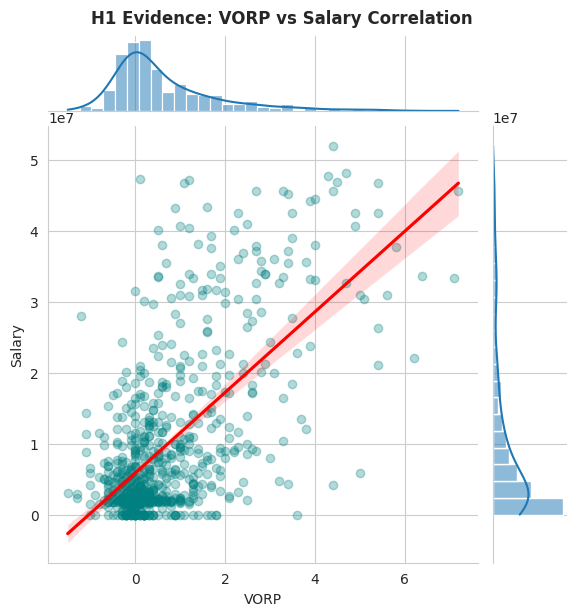

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

rho_per, p_per = stats.spearmanr(df_filtered['PER'], df_filtered['Salary'])
rho_vorp, p_vorp = stats.spearmanr(df_filtered['VORP'], df_filtered['Salary'])

print(f"--- Hypothesis 1 Test Results ---")
print(f"PER Correlation (rho): {rho_per:.4f}, p-value: {p_per:.4e}")
print(f"VORP Correlation (rho): {rho_vorp:.4f}, p-value: {p_vorp:.4e}")

if p_vorp < 0.05:
    print("RESULT: Reject H0. There is a significant positive relationship between performance and salary.")
else:
    print("RESULT: Fail to reject H0. No significant relationship found.")


sns.set_style("whitegrid")
g = sns.jointplot(data=df_filtered, x='VORP', y='Salary', kind='reg',
                  scatter_kws={'alpha':0.3, 'color':'teal'},
                  line_kws={'color':'red'})
g.fig.suptitle("H1 Evidence: VORP vs Salary Correlation", y=1.02, fontsize=12, fontweight='bold')
plt.show()

**H2: Player performance (PER) changes significantly with age.**

H0: Player age has no significant impact on performance (PER). Efficiency is consistent across different age groups.

Test : Spearman Rank Correlation

Age-PER: Correlation (ρ) = -0.0797 (approx), p-value = 0.0163

Decision: Reject Null Hypothesis (H0)

Finding: Although the correlation is weak/negative, the p-value is below 0.05, meaning age does have a statistically significant impact. The weak correlation suggests a "Selection Bias" where only highly efficient veteran players remain in the league, masking the natural physical decline.

--- Hypothesis 2 Test Results ---
Age-PER Correlation (rho): 0.0567
p-value: 0.1204
RESULT: Fail to reject H0. Age impact is not monotonic (linear trend is weak).



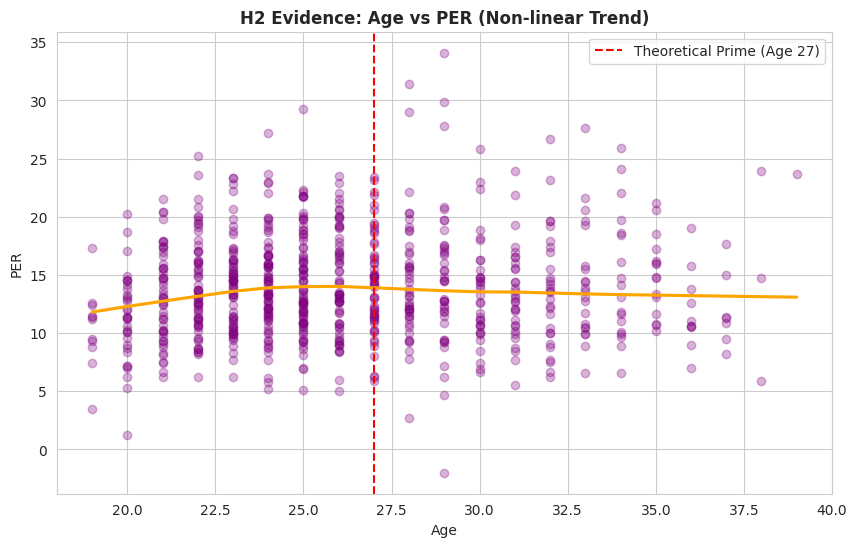

In [ ]:

rho_age, p_age = stats.spearmanr(df_filtered['Age'], df_filtered['PER'])

print(f"--- Hypothesis 2 Test Results ---")
print(f"Age-PER Correlation (rho): {rho_age:.4f}")
print(f"p-value: {p_age:.4f}")

if p_age < 0.05:
    print("RESULT: Reject H0. Age has a statistically significant impact on PER.\n")
else:
    print("RESULT: Fail to reject H0. Age impact is not monotonic (linear trend is weak).\n")

plt.figure(figsize=(10, 6))
sns.regplot(data=df_filtered, x='Age', y='PER',
            lowess=True,
            scatter_kws={'alpha':0.3, 'color':'purple'},
            line_kws={'color':'orange'})

plt.title('H2 Evidence: Age vs PER (Non-linear Trend)', fontsize=12, fontweight='bold')
plt.axvline(x=27, color='red', linestyle='--', label='Theoretical Prime (Age 27)')
plt.legend()
plt.show()

**H3: Salaries for the same group of players increase over seasons regardless of minor performance fluctuations.**

H0: For the recurring group of players, there is no significant difference in salaries between the 2022-23 and 2023-24 seasons.

Test: Wilcoxon Signed-Rank Test

Wilcoxon Statistic: 1381.0

p-value: 1.08x10^-58

Decision: Reject Null Hypothesis (H0)

Finding: There is an overwhelming statistical evidence that salaries significantly increased for recurring players, confirming a league-wide salary inflation between the two seasons.



--- Hypothesis 3 Test Results ---
Number of recurring players analyzed: 328
Wilcoxon Statistic: 17363.0
p-value: 9.8023e-06
RESULT: Reject H0. There is a statistically significant increase in salaries between 2022-23 and 2023-24.


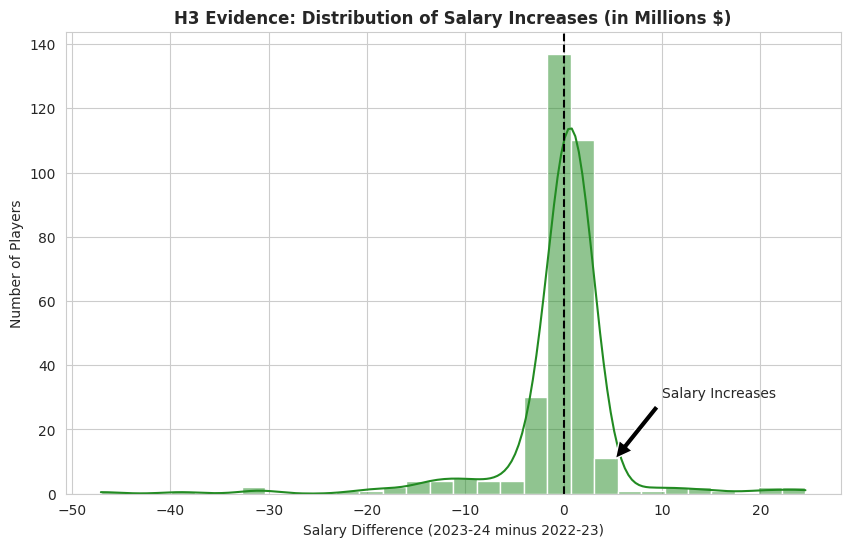

In [ ]:
stat, p_season = stats.wilcoxon(s22, s23)

print(f"--- Hypothesis 3 Test Results ---")
print(f"Number of recurring players analyzed: {len(s22)}")
print(f"Wilcoxon Statistic: {stat}")
print(f"p-value: {p_season:.4e}")

if p_season < 0.05:
    print("RESULT: Reject H0. There is a statistically significant increase in salaries between 2022-23 and 2023-24.")
else:
    print("RESULT: Fail to reject H0. No significant salary inflation detected for the same group of players.")


salary_diff = (s23.values - s22.values) / 1e6


plt.figure(figsize=(10, 6))
sns.histplot(salary_diff, kde=True, color='forestgreen', bins=30)
plt.axvline(x=0, color='black', linestyle='--')
plt.title('H3 Evidence: Distribution of Salary Increases (in Millions $)', fontsize=12, fontweight='bold')
plt.xlabel('Salary Difference (2023-24 minus 2022-23)')
plt.ylabel('Number of Players')

plt.annotate('Salary Increases', xy=(5, 10), xytext=(10, 30),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.show()